In [ ]:
## plot the small square 

Using variable: water_depth


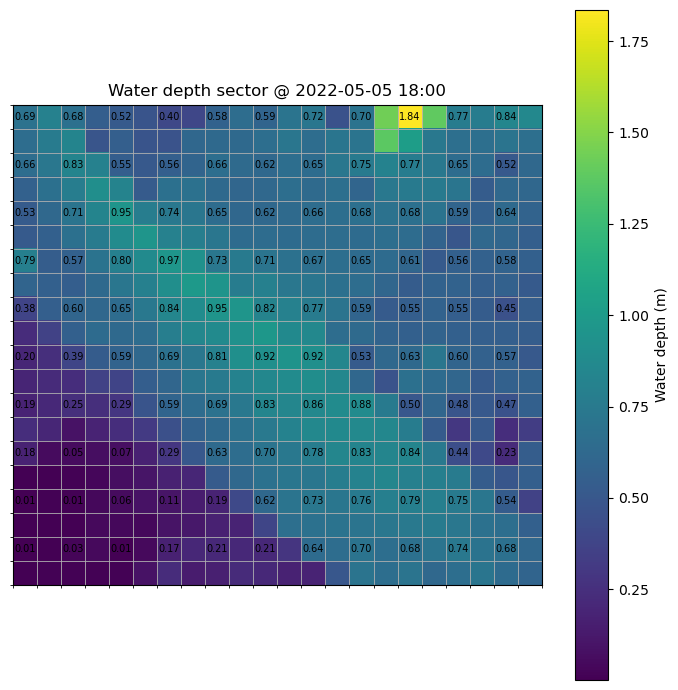

Saved: zell_sector_waterdepth_20220505T1800_pixels.png


In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# --- 1) INPUTS ---
# Put here your *water depth* NetCDF (NOT combiprecip)
nc_wd = "/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Zell_2m_accv14/Zell_2m_accv14_Combiprecip.nc"  # <-- change name

t_sel = np.datetime64("2022-05-05T18:00:00.000000000")

# Your QGIS box (EPSG:2056) from the screenshot
xmin = 2704046.274
xmax = 2704089.994
ymin = 1255707.782
ymax = 1255748.948

out_png = "zell_sector_waterdepth_20220505T1800_pixels.png"

# --- 2) LOAD ---
ds = xr.open_dataset(nc_wd)

# Select time (your dataset uses REFERENCE_TS)
ds_t = ds.sel(REFERENCE_TS=t_sel)

# Pick the variable automatically (or set it manually if you know it)
# e.g. varname = "water_depth" or "h" or similar
varname = list(ds_t.data_vars)[0]
da = ds_t[varname]
print("Using variable:", varname)

# --- 3) CROP TO BOX ---
y_vals = ds_t["y"].values
x_slice = slice(xmin, xmax)

# y can be descending in Swiss grids; choose correct slice direction
if y_vals[0] > y_vals[-1]:
    y_slice = slice(ymax, ymin)
else:
    y_slice = slice(ymin, ymax)

da_crop = da.sel(x=x_slice, y=y_slice)

# Convert to array and handle nodata
arr = da_crop.values.astype(float)
fill = da_crop.attrs.get("_FillValue", None)
if fill is not None:
    arr[arr == fill] = np.nan

# --- 4) PLOT PIXELS + VALUES INSIDE CELLS ---
fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(arr, origin="upper", interpolation="none")  # interpolation none = crisp pixels

# Pixel grid
ax.set_xticks(np.arange(-0.5, arr.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, arr.shape[0], 1), minor=True)
ax.grid(which="minor", linewidth=0.6)

# If too many cells, label every 2nd or 3rd (60x60 is usually too dense)
label_every = 2  # set to 1 if you *really* want every cell labeled

for i in range(0, arr.shape[0], label_every):
    for j in range(0, arr.shape[1], label_every):
        v = arr[i, j]
        if np.isfinite(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7)

ax.set_xticks([])
ax.set_yticks([])
plt.colorbar(im, ax=ax, label="Water depth (m)")
ax.set_title("Water depth sector @ 2022-05-05 18:00")
plt.tight_layout()
plt.savefig(out_png, dpi=300)
plt.show()

print("Saved:", out_png)

